## Chuẩn bị Data (California Housing)

In [10]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# Lấy data thực tế
data = fetch_california_housing()
X = data.data
y = data.target

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Thêm cột bias (X0 = 1) để tính intercept
X = np.c_[np.ones(X.shape[0]), X]


## Hàm Loss và Gradient cho Linear Regression

In [11]:
def compute_loss(X, y, weights):
    m = len(y)
    predictions = X @ weights
    loss = (1/(2*m)) * np.sum((predictions - y) ** 2)
    return loss

def compute_gradient(X, y, weights):
    m = len(y)
    predictions = X @ weights
    gradient = (1/m) * (X.T @ (predictions - y))
    return gradient


## Gradient Descent - Hỗ trợ Batch Size, Learning Rate, Init Weights

In [14]:
def gradient_descent(X, y, lr, epochs, batch_size, init_type="random"):
    m, n = X.shape
    
    # Khởi tạo tham số (weights)
    if init_type == "random":
        weights = np.random.randn(n)
    elif init_type == "zeros":
        weights = np.zeros(n)
    elif init_type == "xavier":
        weights = np.random.randn(n) * np.sqrt(1/n)
    else:
        raise ValueError("Unknown init_type")

    loss_history = []
    
    for epoch in range(epochs):
        # Mini-batch Gradient Descent
        indices = np.random.permutation(m)
        for i in range(0, m, batch_size):
            batch_indices = indices[i:i+batch_size]
            X_batch = X[batch_indices]
            y_batch = y[batch_indices]

            gradient = compute_gradient(X_batch, y_batch, weights)
            weights -= lr * gradient

        loss = compute_loss(X, y, weights)
        loss_history.append(loss)

    # QUAN TRỌNG: Trả về cả weights và loss_history
    return weights, loss_history


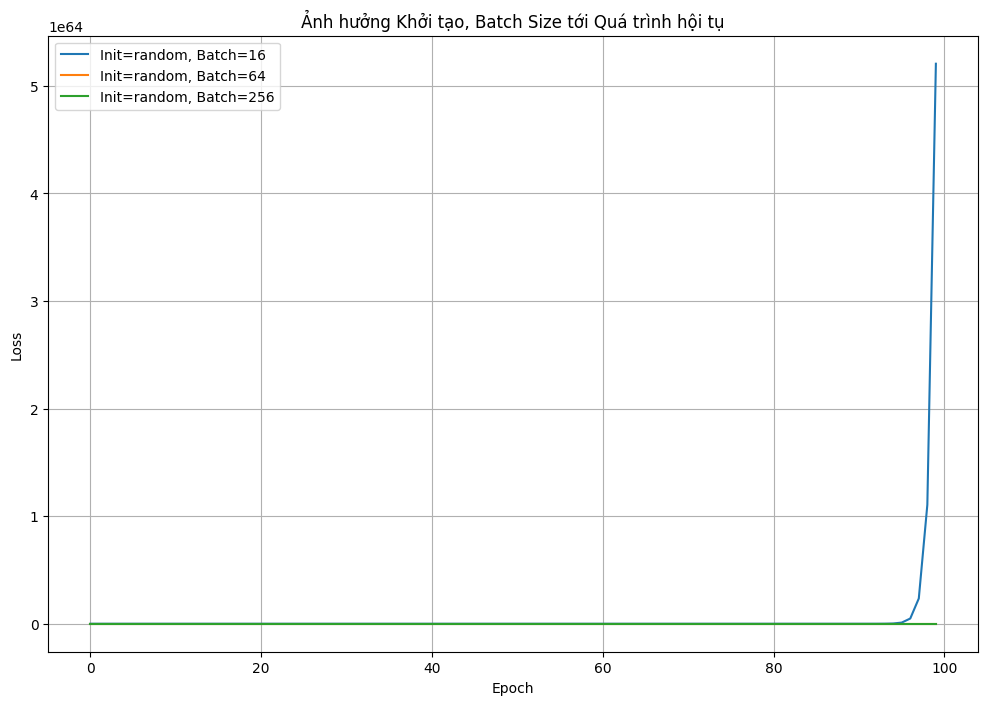

In [16]:
epochs = 100
lr = 0.01
batch_sizes = [16, 64, 256]
init_types = ['random']

plt.figure(figsize=(12, 8))

for init in init_types:
    for batch_size in batch_sizes:
        _, loss_history = gradient_descent(X, y, lr, epochs, batch_size, init_type=init)
        label = f'Init={init}, Batch={batch_size}'
        plt.plot(range(epochs), loss_history, label=label)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Ảnh hưởng Khởi tạo, Batch Size tới Quá trình hội tụ')
plt.legend()
plt.grid(True)
plt.show()


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Sinh dữ liệu ngẫu nhiên đơn giản
np.random.seed(42)
X = np.random.randint(1, 100, size=(100, 1))
y = 2 * X.flatten() + np.random.randint(-10, 10, size=100)  # y = 2x + noise
X = np.c_[np.ones(X.shape[0]), X]  # Thêm bias term

# Hàm tính loss (MSE)
def compute_loss(X, y, weights):
    predictions = X @ weights
    return np.mean((predictions - y) ** 2)

# Hàm tính gradient
def compute_gradient(X, y, weights):
    predictions = X @ weights
    return (2 / len(y)) * (X.T @ (predictions - y))

# Hàm Gradient Descent mở rộng
def gradient_descent(X, y, lr, epochs, batch_size, init_type="random"):
    m, n = X.shape

    # Khởi tạo weights theo kiểu mong muốn
    if init_type == "random":
        weights = np.random.randn(n)
    elif init_type == "zeros":
        weights = np.zeros(n)
    elif init_type == "xavier":
        weights = np.random.randn(n) * np.sqrt(1/n)
    else:
        raise ValueError("init_type không hợp lệ")

    loss_history = []

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        for i in range(0, m, batch_size):
            batch_indices = indices[i:i+batch_size]
            X_batch = X[batch_indices]
            y_batch = y[batch_indices]

            gradient = compute_gradient(X_batch, y_batch, weights)
            weights -= lr * gradient

        loss = compute_loss(X, y, weights)
        loss_history.append(loss)

    return weights, loss_history


d:\Python_idle\Lib\site-packages\numpy\core\_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\admin\AppData\Local\Temp\ipykernel_11268\1204674428.py:13: RuntimeWarning: overflow encountered in square
  return np.mean((predictions - y) ** 2)
C:\Users\admin\AppData\Local\Temp\ipykernel_11268\1204674428.py:18: RuntimeWarning: overflow encountered in matmul
  return (2 / len(y)) * (X.T @ (predictions - y))
C:\Users\admin\AppData\Local\Temp\ipykernel_11268\1204674428.py:44: RuntimeWarning: invalid value encountered in subtract
  weights -= lr * gradient


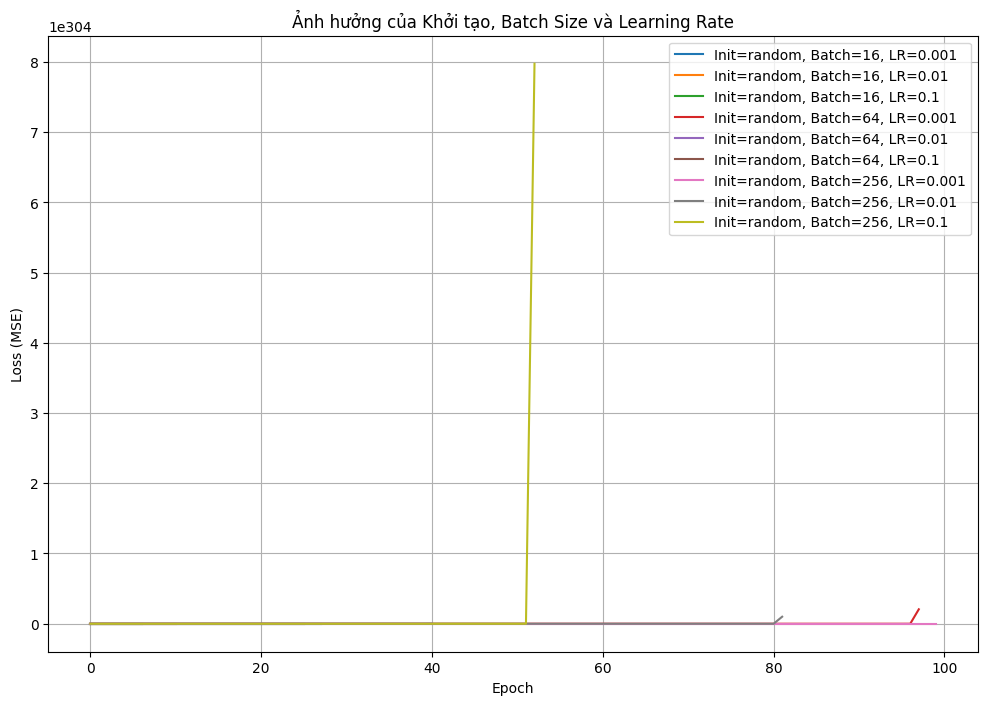

In [18]:
# Cấu hình thử nghiệm
epochs = 100
batch_sizes = [16, 64, 256]
init_types = ['random']
learning_rates = [0.001, 0.01, 0.1]  # Nhiều learning rate

plt.figure(figsize=(12, 8))

for init in init_types:
    for batch_size in batch_sizes:
        for lr in learning_rates:
            _, loss_history = gradient_descent(X, y, lr, epochs, batch_size, init_type=init)
            label = f'Init={init}, Batch={batch_size}, LR={lr}'
            plt.plot(range(epochs), loss_history, label=label)

plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Ảnh hưởng của Khởi tạo, Batch Size và Learning Rate')
plt.legend()
plt.grid(True)
plt.show()


In [22]:
from nbconvert import PDFExporter
import nbformat

# Load the notebook file
notebook_path = 'demo (1).ipynb'
pdf_path = 'demo (1).pdf'

with open(notebook_path, 'r', encoding='utf-8') as file:
    notebook_content = nbformat.read(file, as_version=4)

# Convert to PDF
pdf_exporter = PDFExporter()
pdf_exporter.exclude_input = False  # Include code cells
pdf_data, _ = pdf_exporter.from_notebook_node(notebook_content)

# Save to PDF file
with open(pdf_path, 'wb') as pdf_file:
    pdf_file.write(pdf_data)

# Provide the file link to the user
pdf_path


PandocMissing: Pandoc wasn't found.
Please check that pandoc is installed:
https://pandoc.org/installing.html

In [23]:
pip pandoc

Note: you may need to restart the kernel to use updated packages.


ERROR: unknown command "pandoc"

